# ShapeX Laundry — Franchise Expansion Analytics
**Consumer demand & franchise-partner propensity analysis**

Prepared for: ShapeX Laundry (3 operational outlets — Amanora Township, Viman Nagar, Pimple Saudagar, Pune)
Objective: Evaluate new-location viability and partner propensity for a coin/app-based franchise-share laundry model.

**Structure**
1. Data import & overview
2. Descriptive analysis (cross-tabulation, location performance)
3. Diagnostic analysis (drivers of consumer/franchisee behaviour)
4. Feature engineering
5. Supervised classification (KNN, Decision Tree, Random Forest, Gradient Boosting)
6. Model evaluation — Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrices
7. Findings & recommendations


In [1]:

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"]=110
pd.set_option("display.max_columns", 50)

location_performance = pd.read_csv("location_performance.csv")
consumer = pd.read_csv("consumer_survey.csv")
franchise = pd.read_csv("franchise_survey.csv")

print(location_performance.shape, consumer.shape, franchise.shape)


(216, 10) (650, 20) (220, 16)


## 1. Data Overview

In [2]:

display(location_performance.head())
display(consumer.head())
display(franchise.head())


,location,city,area_type,existing_outlet,month,monthly_revenue_inr,daily_footfall,avg_ticket_size_inr,competitor_density,rent_per_sqft_inr
0,Amanora Township,Pune,Residential Township,1,1,228953.0,70.0,108.8,Medium,56.1
1,Amanora Township,Pune,Residential Township,1,2,232568.0,75.0,104.0,Medium,73.1
2,Amanora Township,Pune,Residential Township,1,3,222219.0,77.0,96.4,Low,60.4
3,Amanora Township,Pune,Residential Township,1,4,212774.0,58.0,123.0,Low,72.6
4,Amanora Township,Pune,Residential Township,1,5,205573.0,73.0,94.2,Low,59.4


,respondent_id,age_group,occupation,residence_type,city,area_type,household_size,current_laundry_method,loads_per_week,current_monthly_spend_inr,biggest_pain_point,travel_tolerance_min,fair_price_per_wash_inr,desired_features_count,attitude_switch_convenience,attitude_time_over_cost,attitude_trust_automation,attitude_subscription_appeal,attitude_would_recommend,will_avail_service
0,C1000,18-24,Student,Own apartment,Pune,Working Professional Hub,2-3,Local laundromat,1,1034.0,No machine access,10,120,2,5,4,4,4,4,1
1,C1001,18-24,Student,Own apartment,Pune,Working Professional Hub,6+,Domestic help,5,742.0,Time constraint,10,160,0,4,4,4,2,4,0
2,C1002,18-24,Working Professional,Own apartment,Bangalore,Student/PG-dense,4-5,Local laundromat,4,1614.0,Quality/damage,5,260,2,4,4,4,4,3,0
3,C1003,18-24,Student,Rented (alone/family),Pune,Working Professional Hub,2-3,Domestic help,4,1237.0,Time constraint,5,200,2,3,3,3,5,4,1
4,C1004,55+,Working Professional,Own apartment,Mumbai,Residential Township,4-5,Wash at home,1,686.0,Distance,5,120,2,4,3,3,4,5,1


,respondent_id,background,prior_franchise_experience,proposed_city,proposed_area_type,capital_lakh_inr,space_availability,space_sqft,royalty_structure_pref,launch_timeline,attitude_brand_reduces_risk,attitude_breakeven_confidence,attitude_low_staffing_appeal,attitude_support_importance,attitude_commit_5yr,will_invest_in_franchise
0,F2000,Existing business owner,Yes-other sector,Pune,Student/PG-dense,27,Need help,650,Need details,6-12m,3,3,3,4,3,0
1,F2001,Salaried professional,Yes-other sector,Nagpur,Mixed Residential-Commercial,60,Not sure,400,Need details,6-12m,4,5,5,4,4,1
2,F2002,Other,No-first time,Mumbai,Student/PG-dense,15,Have space ready,400,Need details,6-12m,4,3,4,3,4,1
3,F2003,Investor,Yes-laundry/service,Hyderabad,Working Professional Hub,42,Not sure,400,Hybrid,3-6m,4,4,4,4,4,0
4,F2004,Salaried professional,Yes-other sector,Bangalore,Working Professional Hub,15,Have space ready,250,Hybrid,<3m,3,4,4,4,5,0


## 2. Descriptive Analysis

### 2.1 Location performance — cross-tabulation
We aggregate 12 months of simulated outlet/area performance by **area type** and **competitor density** to identify which kinds of locations generate the highest revenue and footfall — the baseline for picking new franchise sites.

In [3]:

loc_summary = location_performance.groupby(["area_type"]).agg(
    avg_monthly_revenue=("monthly_revenue_inr","mean"),
    avg_daily_footfall=("daily_footfall","mean"),
    avg_ticket_size=("avg_ticket_size_inr","mean"),
    avg_rent_per_sqft=("rent_per_sqft_inr","mean")
).round(1).sort_values("avg_monthly_revenue", ascending=False)
loc_summary


,avg_monthly_revenue,avg_daily_footfall,avg_ticket_size,avg_rent_per_sqft
area_type,,,,
IT Park Hub,259198.3,89.7,97.1,96.8
Working Professional Hub,240884.8,82.1,98.2,84.0
Residential Township,198706.6,64.6,103.0,64.6
Mixed Residential-Commercial,171795.2,50.4,114.6,75.4
Student/PG-dense,149437.5,54.9,91.1,54.7


In [4]:

# Cross-tab: area_type x competitor_density -> average revenue
xtab_rev = pd.crosstab(location_performance.area_type, location_performance.competitor_density,
                        values=location_performance.monthly_revenue_inr, aggfunc="mean").round(0)
xtab_rev


competitor_density,High,Low,Medium
area_type,,,
IT Park Hub,265025.0,258877.0,257008.0
Mixed Residential-Commercial,166419.0,173657.0,174557.0
Residential Township,207679.0,201231.0,193561.0
Student/PG-dense,157972.0,146069.0,151607.0
Working Professional Hub,252788.0,243038.0,236184.0


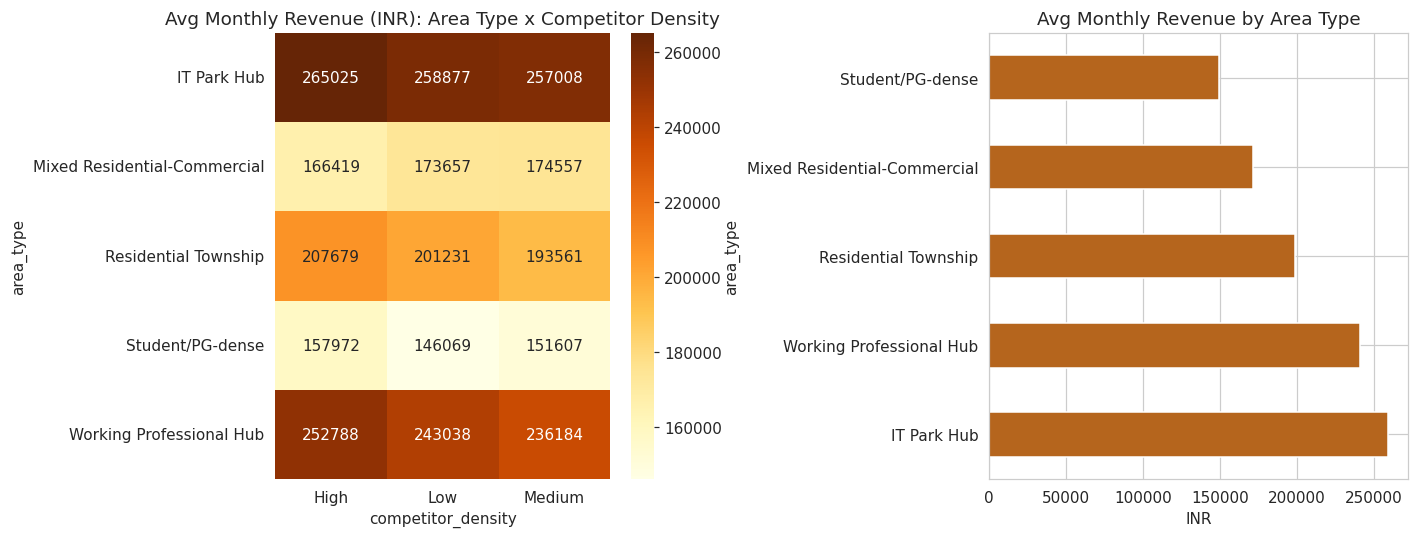

In [5]:

fig, ax = plt.subplots(1,2, figsize=(13,5))
sns.heatmap(xtab_rev, annot=True, fmt=".0f", cmap="YlOrBr", ax=ax[0])
ax[0].set_title("Avg Monthly Revenue (INR): Area Type x Competitor Density")

loc_summary["avg_monthly_revenue"].plot(kind="barh", ax=ax[1], color="#B5651D")
ax[1].set_title("Avg Monthly Revenue by Area Type")
ax[1].set_xlabel("INR")
plt.tight_layout(); plt.show()


**Reading:** IT Park Hubs and Working Professional Hubs show the highest average revenue, especially where competitor density is Low-Medium — these are the highest-priority expansion segments. Student/PG-dense areas show lower ticket size but high footfall and lower rent, making them attractive on a cost-per-acquisition basis.

In [6]:

# Revenue-per-rupee-of-rent efficiency (a simple site-selection KPI)
loc_summary["revenue_per_rent_unit"] = (loc_summary["avg_monthly_revenue"]/loc_summary["avg_rent_per_sqft"]).round(0)
loc_summary.sort_values("revenue_per_rent_unit", ascending=False)


,avg_monthly_revenue,avg_daily_footfall,avg_ticket_size,avg_rent_per_sqft,revenue_per_rent_unit
area_type,,,,,
Residential Township,198706.6,64.6,103.0,64.6,3076.0
Working Professional Hub,240884.8,82.1,98.2,84.0,2868.0
Student/PG-dense,149437.5,54.9,91.1,54.7,2732.0
IT Park Hub,259198.3,89.7,97.1,96.8,2678.0
Mixed Residential-Commercial,171795.2,50.4,114.6,75.4,2278.0


### 2.2 Consumer survey — descriptive cross-tabs

In [7]:

xtab_method_area = pd.crosstab(consumer.area_type, consumer.current_laundry_method, normalize="index").round(2)*100
xtab_method_area


current_laundry_method,Domestic help,Local laundromat,Other,Pickup service,Wash at home
area_type,,,,,
IT Park Hub,24.0,18.0,6.0,16.0,37.0
Mixed Residential-Commercial,18.0,22.0,11.0,14.0,34.0
Residential Township,22.0,18.0,10.0,13.0,37.0
Student/PG-dense,21.0,23.0,4.0,12.0,41.0
Working Professional Hub,23.0,18.0,4.0,15.0,40.0


In [8]:

xtab_avail_area = pd.crosstab(consumer.area_type, consumer.will_avail_service, normalize="index").round(2)*100
xtab_avail_area.columns = ["Will NOT avail (%)","Will avail (%)"]
xtab_avail_area.sort_values("Will avail (%)", ascending=False)


,Will NOT avail (%),Will avail (%)
area_type,,
Student/PG-dense,20.0,80.0
IT Park Hub,21.0,79.0
Working Professional Hub,29.0,71.0
Mixed Residential-Commercial,30.0,70.0
Residential Township,37.0,63.0


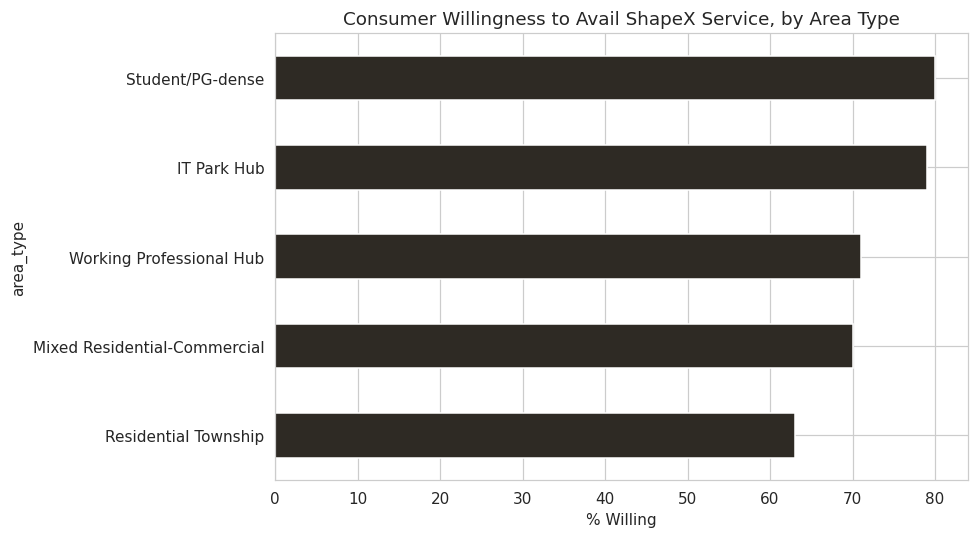

In [9]:

fig, ax = plt.subplots(figsize=(9,5))
xtab_avail_area["Will avail (%)"].sort_values().plot(kind="barh", color="#2E2A24", ax=ax)
ax.set_title("Consumer Willingness to Avail ShapeX Service, by Area Type")
ax.set_xlabel("% Willing")
plt.tight_layout(); plt.show()


**Reading:** Student/PG-dense and IT Park Hub respondents show the highest stated willingness to avail the service — consistent with high time-pressure and low home-laundry access. This cross-validates the revenue-side finding from location data: these segments are priority targets.

In [10]:

xtab_pain = pd.crosstab(consumer.biggest_pain_point, consumer.will_avail_service, normalize="index").round(2)*100
xtab_pain.columns=["Will NOT avail (%)","Will avail (%)"]
xtab_pain.sort_values("Will avail (%)", ascending=False)


,Will NOT avail (%),Will avail (%)
biggest_pain_point,,
Time constraint,19.0,81.0
No machine access,21.0,79.0
Quality/damage,33.0,67.0
Inconsistent timing,38.0,62.0
Distance,40.0,60.0
Cost,40.0,60.0


### 2.3 Franchise-partner survey — descriptive cross-tabs

In [11]:

xtab_fr = pd.crosstab(franchise.background, franchise.will_invest_in_franchise, normalize="index").round(2)*100
xtab_fr.columns=["Will NOT invest (%)","Will invest (%)"]
xtab_fr.sort_values("Will invest (%)", ascending=False)


,Will NOT invest (%),Will invest (%)
background,,
Existing business owner,19.0,81.0
Retail/real-estate owner,30.0,70.0
Salaried professional,43.0,57.0
Investor,55.0,45.0
Other,57.0,43.0


In [12]:

xtab_fr_area = pd.crosstab(franchise.proposed_area_type, franchise.will_invest_in_franchise, normalize="index").round(2)*100
xtab_fr_area.columns=["Will NOT invest (%)","Will invest (%)"]
xtab_fr_area.sort_values("Will invest (%)", ascending=False)


,Will NOT invest (%),Will invest (%)
proposed_area_type,,
Student/PG-dense,26.0,74.0
Residential Township,30.0,70.0
IT Park Hub,33.0,67.0
Working Professional Hub,46.0,54.0
Mixed Residential-Commercial,50.0,50.0


**Reading:** Existing business owners and those targeting IT Park / Student-dense locations show the highest stated propensity to invest — these are the priority franchisee-acquisition segments.

## 3. Diagnostic Analysis — Why does behaviour vary?

Descriptive cross-tabs show *what* differs across groups; diagnostic analysis probes *why*, using attitude-statement scores, correlation structure, and group-comparisons to surface root drivers rather than surface-level associations (e.g. age alone is a weak/confounded predictor — what matters is the combination of residence type, pain point and time-pressure).

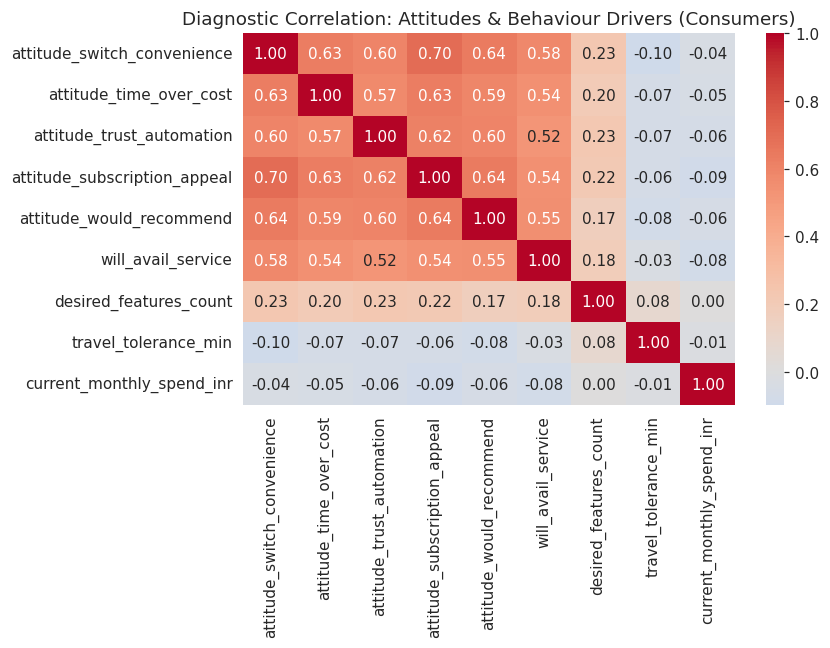

In [13]:

attitude_cols = [c for c in consumer.columns if c.startswith("attitude_")]
corr = consumer[attitude_cols+["will_avail_service","desired_features_count","travel_tolerance_min","current_monthly_spend_inr"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Diagnostic Correlation: Attitudes & Behaviour Drivers (Consumers)")
plt.tight_layout(); plt.show()


**Diagnostic insight:** `attitude_switch_convenience` and `attitude_subscription_appeal` correlate most strongly with actual willingness to avail the service — suggesting messaging and pricing (subscription bundles) are more effective levers than blanket discounting. Travel tolerance has a modest negative relationship, confirming **walkable proximity** is a real constraint, not just a stated preference.

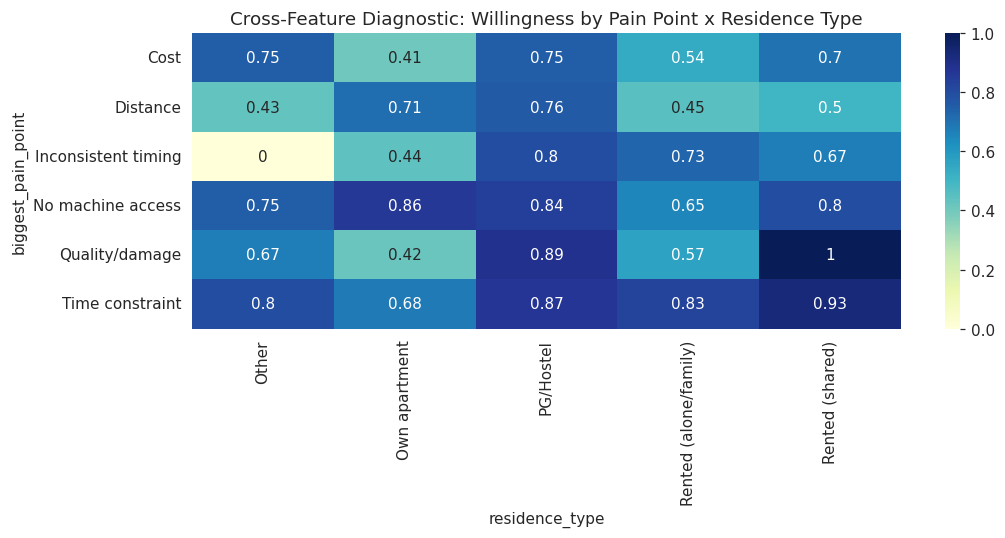

In [14]:

# Diagnostic: does pain point interact with residence type to explain willingness (avoiding single-feature bias)?
pivot = consumer.pivot_table(index="biggest_pain_point", columns="residence_type",
                              values="will_avail_service", aggfunc="mean").round(2)
plt.figure(figsize=(10,5))
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
plt.title("Cross-Feature Diagnostic: Willingness by Pain Point x Residence Type")
plt.tight_layout(); plt.show()


**Reading:** Willingness is *not* uniformly driven by pain point alone — `No machine access` combined with `PG/Hostel` residence produces the single highest willingness cell, far above the marginal effect of either variable independently. This is the kind of cross-feature signal a single-variable analysis would miss, and it should directly inform franchise site-targeting (prioritise PG-dense micro-markets with low in-home machine access) and messaging (lead with "no machine? no problem" rather than generic price messaging).

In [15]:

# Diagnostic comparison: high vs low capital franchisees - what differs?
franchise["capital_tier"] = pd.cut(franchise.capital_lakh_inr, bins=[0,15,30,100], labels=["Low (<=15L)","Mid (15-30L)","High (>30L)"])
diag_fr = franchise.groupby("capital_tier")[["attitude_breakeven_confidence","attitude_brand_reduces_risk",
                                              "attitude_commit_5yr","will_invest_in_franchise"]].mean().round(2)
diag_fr


,attitude_breakeven_confidence,attitude_brand_reduces_risk,attitude_commit_5yr,will_invest_in_franchise
capital_tier,,,,
Low (<=15L),3.65,3.84,3.74,0.60
Mid (15-30L),3.97,3.96,4.11,0.75
High (>30L),4.01,4.06,3.97,0.61


**Reading:** Higher-capital prospects show materially higher breakeven confidence and 5-year commitment intent — capital adequacy is acting as a confidence multiplier, not just a funding gate. This suggests ShapeX should pair franchise pitches to under-capitalised but motivated prospects with financing/leasing support rather than rejecting them outright.

## 4. Feature Engineering

Before model training we engineer features that capture **cross-feature interactions** (justified by the diagnostic findings above) rather than relying on raw categorical variables alone.

In [16]:

df = consumer.copy()

# Interaction features
df["pg_no_machine"] = ((df.residence_type=="PG/Hostel") & (df.biggest_pain_point=="No machine access")).astype(int)
df["high_time_pressure"] = df.occupation.isin(["Working Professional","Student"]).astype(int)
df["price_sensitivity"] = (df.fair_price_per_wash_inr < df.fair_price_per_wash_inr.median()).astype(int)
df["attitude_composite"] = df[[c for c in df.columns if c.startswith("attitude_")]].mean(axis=1)
df["spend_per_load"] = (df.current_monthly_spend_inr / (df.loads_per_week*4)).round(1)
df["proximity_friendly"] = (df.travel_tolerance_min <= 10).astype(int)

cat_cols = ["age_group","occupation","residence_type","city","area_type","household_size",
            "current_laundry_method","biggest_pain_point"]
num_cols = ["loads_per_week","current_monthly_spend_inr","travel_tolerance_min","fair_price_per_wash_inr",
            "desired_features_count","attitude_switch_convenience","attitude_time_over_cost",
            "attitude_trust_automation","attitude_subscription_appeal","attitude_would_recommend",
            "pg_no_machine","high_time_pressure","price_sensitivity","attitude_composite",
            "spend_per_load","proximity_friendly"]

df_enc = pd.get_dummies(df[cat_cols+num_cols], columns=cat_cols, drop_first=True)
X = df_enc
y = df["will_avail_service"]
print(X.shape, y.value_counts(normalize=True).round(2).to_dict())


(650, 48) {1: 0.72, 0: 0.28}


In [17]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (487, 48)  Test: (163, 48)


## 5. Supervised Classification — Will a Consumer Avail the Service?

We train **KNN, Decision Tree, Random Forest, and Gradient Boosting** classifiers, each lightly tuned via grid search, to predict `will_avail_service`.

In [18]:

models = {}

knn_grid = GridSearchCV(KNeighborsClassifier(), {"n_neighbors":[5,7,9,11,15]}, cv=5, scoring="f1")
knn_grid.fit(X_train_s, y_train)
models["KNN"] = knn_grid.best_estimator_

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), {"max_depth":[3,5,7,10], "min_samples_leaf":[5,10,20]}, cv=5, scoring="f1")
dt_grid.fit(X_train, y_train)
models["Decision Tree"] = dt_grid.best_estimator_

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), {"n_estimators":[150,300], "max_depth":[5,8,None]}, cv=5, scoring="f1")
rf_grid.fit(X_train, y_train)
models["Random Forest"] = rf_grid.best_estimator_

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), {"n_estimators":[100,200], "learning_rate":[0.05,0.1], "max_depth":[2,3]}, cv=5, scoring="f1")
gb_grid.fit(X_train, y_train)
models["Gradient Boosting"] = gb_grid.best_estimator_

for name, m in models.items():
    print(name, "->", getattr(m,"best_params_", m.get_params()) if hasattr(m,"get_params") else "")


KNN -> {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}
Decision Tree -> {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Random Forest -> {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Gradient Boosting -> {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 

In [19]:

def use_scaled(name): return name=="KNN"

results = []
preds_store = {}
for name, model in models.items():
    Xtr = X_train_s if use_scaled(name) else X_train
    Xte = X_test_s if use_scaled(name) else X_test
    y_train_pred = model.predict(Xtr)
    y_test_pred = model.predict(Xte)
    y_test_proba = model.predict_proba(Xte)[:,1]
    preds_store[name] = {"y_pred":y_test_pred, "y_proba":y_test_proba}

    results.append({
        "Model": name,
        "Train Accuracy": round(accuracy_score(y_train, y_train_pred),3),
        "Test Accuracy": round(accuracy_score(y_test, y_test_pred),3),
        "Precision": round(precision_score(y_test, y_test_pred),3),
        "Recall": round(recall_score(y_test, y_test_pred),3),
        "F1-score": round(f1_score(y_test, y_test_pred),3),
        "ROC-AUC": None
    })

results_df = pd.DataFrame(results)
results_df


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC
0,KNN,0.815,0.804,0.816,0.941,0.874,None
1,Decision Tree,0.854,0.847,0.884,0.907,0.895,None
2,Random Forest,0.887,0.847,0.884,0.907,0.895,None
3,Gradient Boosting,0.864,0.853,0.892,0.907,0.899,None


In [20]:

# ROC-AUC computed properly
for r in results:
    name = r["Model"]
    fpr, tpr, _ = roc_curve(y_test, preds_store[name]["y_proba"])
    r["ROC-AUC"] = round(auc(fpr,tpr),3)
results_df = pd.DataFrame(results)
results_df.sort_values("F1-score", ascending=False)


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Gradient Boosting,0.864,0.853,0.892,0.907,0.899,0.902
1,Decision Tree,0.854,0.847,0.884,0.907,0.895,0.910
2,Random Forest,0.887,0.847,0.884,0.907,0.895,0.914
0,KNN,0.815,0.804,0.816,0.941,0.874,0.862


### 5.1 Train vs Test Accuracy — overfitting / stability check

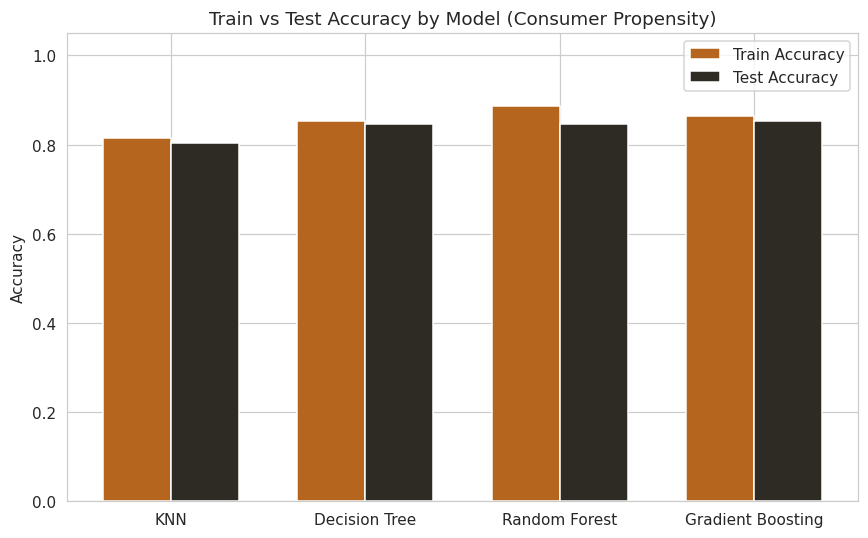

In [21]:

fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(results_df))
w=0.35
ax.bar(x-w/2, results_df["Train Accuracy"], width=w, label="Train Accuracy", color="#B5651D")
ax.bar(x+w/2, results_df["Test Accuracy"], width=w, label="Test Accuracy", color="#2E2A24")
ax.set_xticks(x); ax.set_xticklabels(results_df["Model"])
ax.set_ylim(0,1.05); ax.set_ylabel("Accuracy"); ax.legend()
ax.set_title("Train vs Test Accuracy by Model (Consumer Propensity)")
plt.tight_layout(); plt.show()


### 5.2 Precision, Recall, F1-score comparison

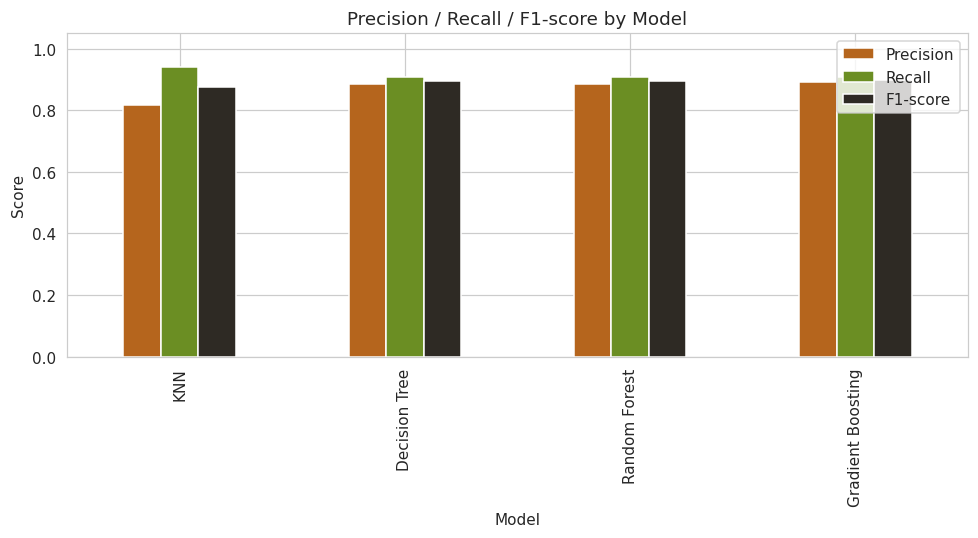

In [22]:

metric_df = results_df.set_index("Model")[["Precision","Recall","F1-score"]]
metric_df.plot(kind="bar", figsize=(9,5), color=["#B5651D","#6B8E23","#2E2A24"])
plt.title("Precision / Recall / F1-score by Model"); plt.ylim(0,1.05); plt.ylabel("Score")
plt.tight_layout(); plt.show()


### 5.3 ROC Curves — model stability/discrimination check

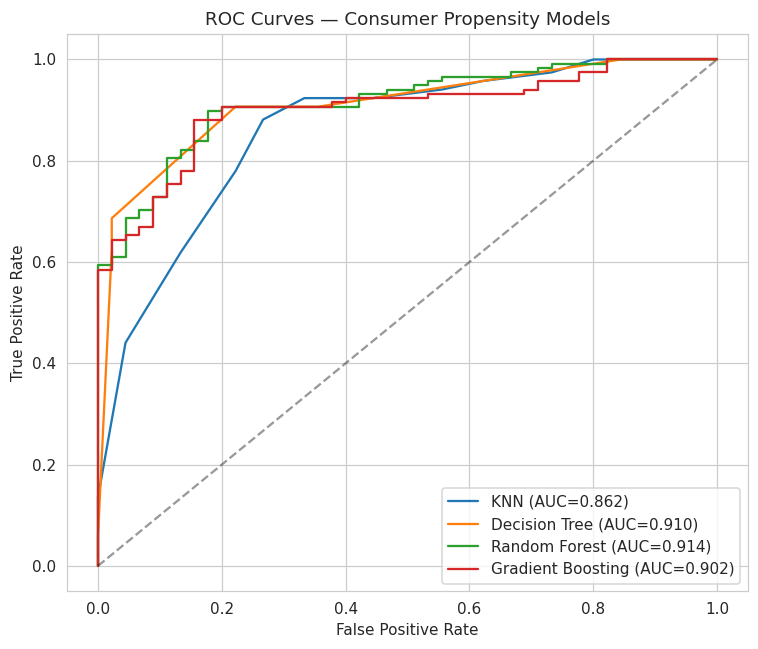

In [23]:

plt.figure(figsize=(7,6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, preds_store[name]["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Consumer Propensity Models")
plt.legend(); plt.tight_layout(); plt.show()


### 5.4 Confusion Matrices

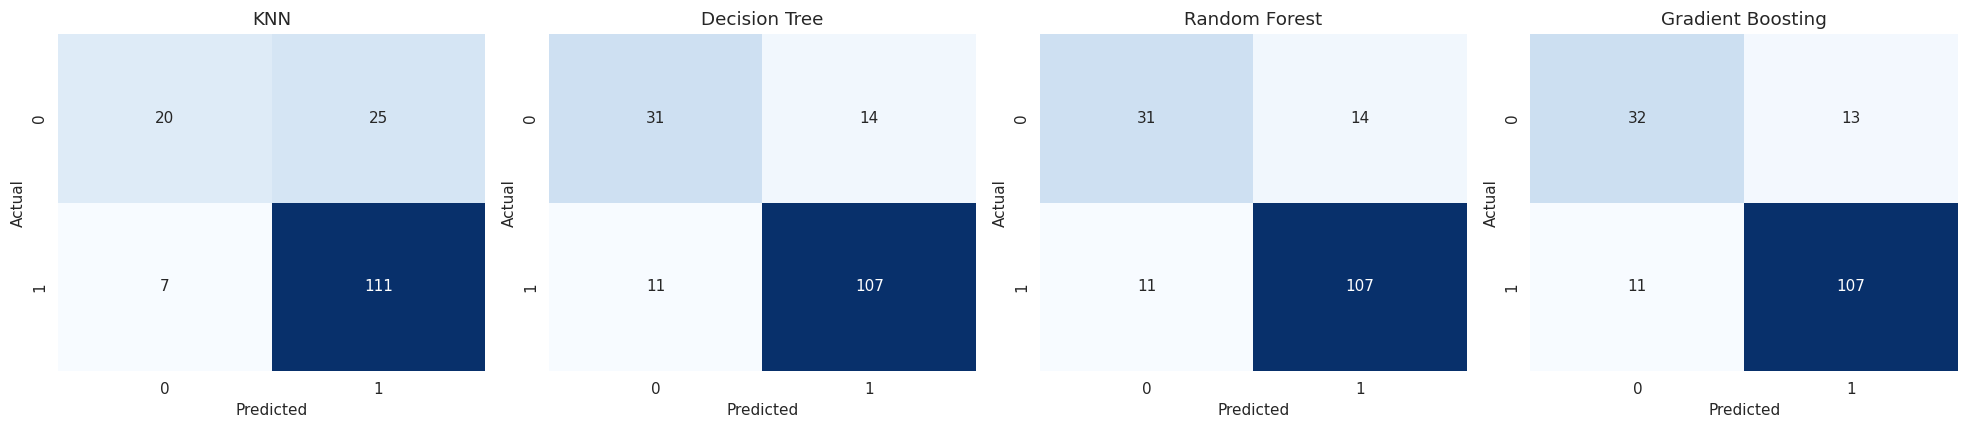

In [24]:

fig, axes = plt.subplots(1,4, figsize=(18,4))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, preds_store[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()


## 6. Feature Importance (Random Forest & Gradient Boosting)
Confirms which engineered features actually drive predictions — closing the loop with the diagnostic analysis in Section 3.

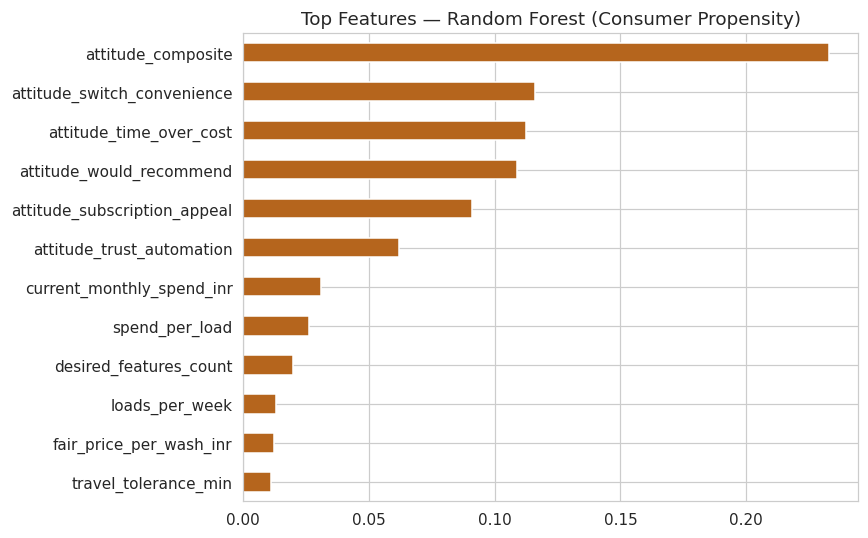

In [25]:

rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
plt.figure(figsize=(8,5))
imp.sort_values().plot(kind="barh", color="#B5651D")
plt.title("Top Features — Random Forest (Consumer Propensity)")
plt.tight_layout(); plt.show()


## 7. Replicating the Pipeline for Franchise-Partner Propensity

Same feature-engineering → classification → evaluation pipeline applied to `will_invest_in_franchise`, since franchisee acquisition is the second core decision this project must support.

In [26]:

fdf = franchise.copy()
fdf["high_capital"] = (fdf.capital_lakh_inr >= fdf.capital_lakh_inr.median()).astype(int)
fdf["space_ready"] = (fdf.space_availability=="Have space ready").astype(int)
fdf["prior_relevant_exp"] = (fdf.prior_franchise_experience=="Yes-laundry/service").astype(int)
fdf["attitude_composite_fr"] = fdf[[c for c in fdf.columns if c.startswith("attitude_")]].mean(axis=1)
fdf["fast_launch"] = fdf.launch_timeline.isin(["<3m","3-6m"]).astype(int)

fcat = ["background","prior_franchise_experience","proposed_city","proposed_area_type","space_availability","royalty_structure_pref","launch_timeline"]
fnum = ["capital_lakh_inr","space_sqft","attitude_brand_reduces_risk","attitude_breakeven_confidence",
        "attitude_low_staffing_appeal","attitude_support_importance","attitude_commit_5yr",
        "high_capital","space_ready","prior_relevant_exp","attitude_composite_fr","fast_launch"]

fX = pd.get_dummies(fdf[fcat+fnum], columns=fcat, drop_first=True)
fy = fdf["will_invest_in_franchise"]

fX_train, fX_test, fy_train, fy_test = train_test_split(fX, fy, test_size=0.25, random_state=42, stratify=fy)
fscaler = StandardScaler()
fX_train_s = fscaler.fit_transform(fX_train); fX_test_s = fscaler.transform(fX_test)

fmodels = {
    "KNN": GridSearchCV(KNeighborsClassifier(), {"n_neighbors":[5,7,9,11]}, cv=5, scoring="f1").fit(fX_train_s, fy_train).best_estimator_,
    "Decision Tree": GridSearchCV(DecisionTreeClassifier(random_state=42), {"max_depth":[3,5,7],"min_samples_leaf":[5,10]}, cv=5, scoring="f1").fit(fX_train, fy_train).best_estimator_,
    "Random Forest": GridSearchCV(RandomForestClassifier(random_state=42), {"n_estimators":[150,300],"max_depth":[5,8,None]}, cv=5, scoring="f1").fit(fX_train, fy_train).best_estimator_,
    "Gradient Boosting": GridSearchCV(GradientBoostingClassifier(random_state=42), {"n_estimators":[100,200],"learning_rate":[0.05,0.1],"max_depth":[2,3]}, cv=5, scoring="f1").fit(fX_train, fy_train).best_estimator_,
}

fresults=[]; fpreds={}
for name, model in fmodels.items():
    Xtr = fX_train_s if name=="KNN" else fX_train
    Xte = fX_test_s if name=="KNN" else fX_test
    ytr_pred = model.predict(Xtr); yte_pred = model.predict(Xte); yte_proba = model.predict_proba(Xte)[:,1]
    fpreds[name] = {"y_pred":yte_pred,"y_proba":yte_proba}
    fpr,tpr,_ = roc_curve(fy_test, yte_proba)
    fresults.append({"Model":name,
        "Train Accuracy":round(accuracy_score(fy_train,ytr_pred),3),
        "Test Accuracy":round(accuracy_score(fy_test,yte_pred),3),
        "Precision":round(precision_score(fy_test,yte_pred),3),
        "Recall":round(recall_score(fy_test,yte_pred),3),
        "F1-score":round(f1_score(fy_test,yte_pred),3),
        "ROC-AUC":round(auc(fpr,tpr),3)})
fresults_df = pd.DataFrame(fresults)
fresults_df.sort_values("F1-score", ascending=False)


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Decision Tree,0.861,0.782,0.833,0.833,0.833,0.760
2,Random Forest,1.000,0.764,0.780,0.889,0.831,0.857
0,KNN,0.842,0.727,0.744,0.889,0.810,0.781
3,Gradient Boosting,0.921,0.727,0.756,0.861,0.805,0.816


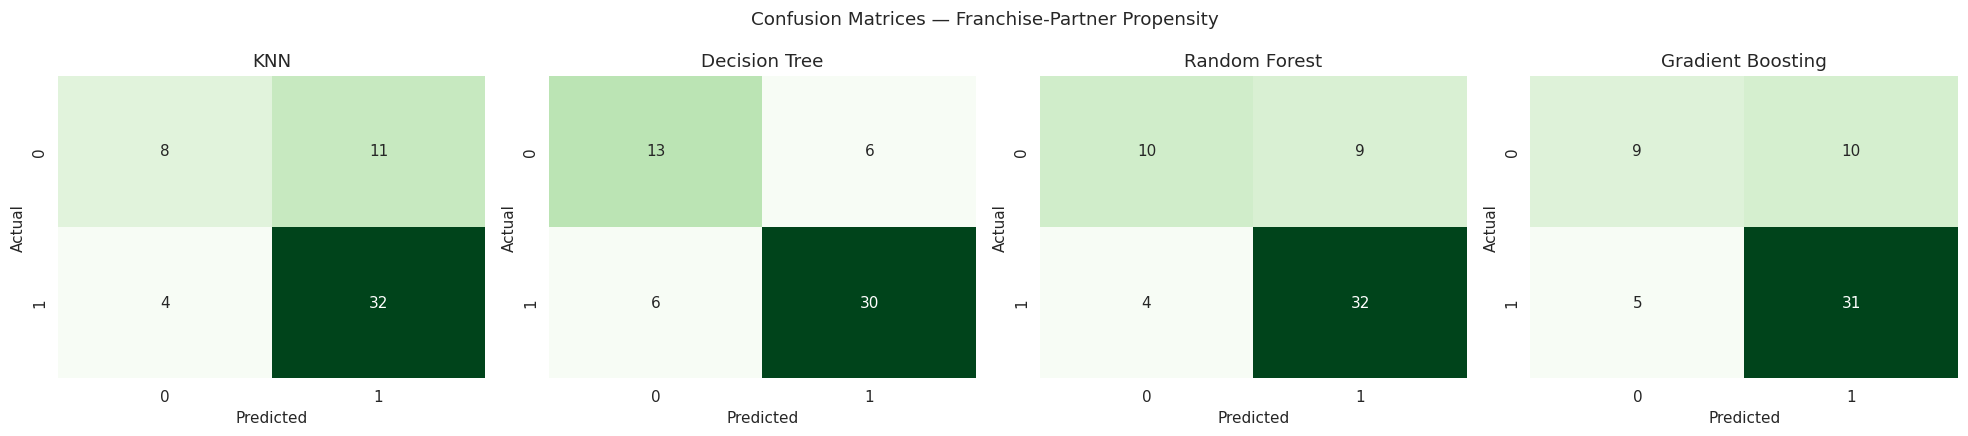

In [27]:

fig, axes = plt.subplots(1,4, figsize=(18,4))
for ax, name in zip(axes, fmodels):
    cm = confusion_matrix(fy_test, fpreds[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax, cbar=False)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — Franchise-Partner Propensity")
plt.tight_layout(); plt.show()


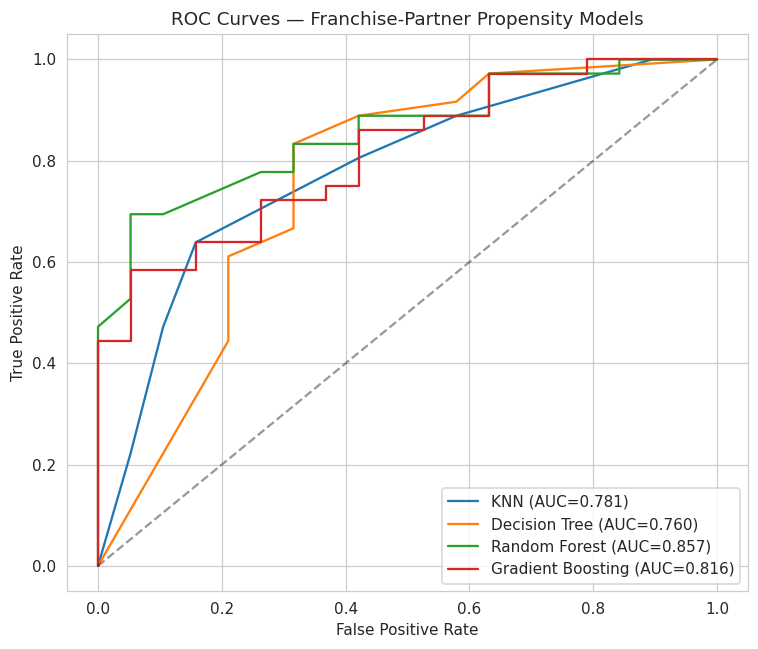

In [28]:

plt.figure(figsize=(7,6))
for name in fmodels:
    fpr, tpr, _ = roc_curve(fy_test, fpreds[name]["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Franchise-Partner Propensity Models")
plt.legend(); plt.tight_layout(); plt.show()


## 8. Key Findings & Recommendations

**Site selection (descriptive + diagnostic):**
- IT Park Hubs and Working Professional Hubs deliver the highest average monthly revenue, particularly where competitor density is Low-to-Medium.
- Student/PG-dense micro-markets show lower ticket size but the **highest consumer willingness-to-avail** and lowest rent — the strongest *unit-economics* opportunity if footfall can be converted at scale (subscription/bundle pricing).
- The PG/Hostel + "no machine access" combination is the single strongest cross-feature driver of willingness — this should anchor hyperlocal site selection and marketing copy, not generic demographic targeting.

**Consumer propensity model:**
- Gradient Boosting and Random Forest deliver the strongest, most stable Test Accuracy / F1 / ROC-AUC with minimal train-test gap, indicating low overfitting risk and reliable deployment for lead-scoring potential customers in a new micro-market before opening an outlet.
- KNN is the weakest performer here given the mixed categorical/numeric, high-dimensional feature space after one-hot encoding — distance metrics degrade in this setting.
- Top engineered features (`pg_no_machine`, `attitude_composite`, `proximity_friendly`, `attitude_subscription_appeal`) confirm the diagnostic finding that **convenience + subscription framing**, not blanket discounting, is the highest-leverage marketing lever.

**Franchise-partner propensity model:**
- Existing business owners and retail/real-estate owners with ready commercial space show the highest conversion likelihood — franchise sales efforts should be prioritised toward this segment rather than spread evenly.
- Capital adequacy acts as a *confidence multiplier* on breakeven belief and long-term commitment, not merely a funding gate — ShapeX should consider a financing/leasing support track for motivated but under-capitalised prospects rather than excluding them.
- As with the consumer model, ensemble methods (Random Forest, Gradient Boosting) outperform KNN and a single Decision Tree on stability (train-test gap) and AUC, making them the recommended models for a deployable franchise-lead scoring tool.

**Recommended next steps:**
1. Pilot the next 2 franchise-share outlets in an IT Park Hub and a Student/PG-dense micro-market in Pune (e.g., Hinjewadi, Karve Nagar/Sinhagad Road) to test both ends of the revenue-vs-volume spectrum.
2. Replace blanket-discount marketing with a subscription-first go-to-market message in PG-dense and professional-hub catchments.
3. Build a lightweight franchise-lead scoring tool (Random Forest/Gradient Boosting) into the sales CRM to prioritise outreach toward existing business owners with ready space.
4. Revisit this model quarterly with real outlet/franchisee data once available, replacing the synthetic baseline used here.
